# 03 - Contraste, seuillage et contours

## Objectif
''' Améliorer la visibilité des défauts potentiels dans les images de fonderie, puis isoler des régions utiles par seuillage et détection de contours.'''

## Travail réalisé
''' - amélioration du contraste
- égalisation d’histogramme
- CLAHE
- seuillage simple
- seuillage automatique d’Otsu
- seuillage adaptatif
- détection de contours
- comparaison visuelle des résultats '''

In [24]:
# ==========================================
# 1. Imports
# ==========================================

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

%load_ext autoreload
%autoreload 2

import cv2
import numpy as np
import matplotlib.pyplot as plt
import random

from src.preprocessing import preprocess_image
from src.filtering import apply_gaussian_filter, apply_median_filter

%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
# ==========================================
# 2. Fonctions utilitaires
# ==========================================

DATASET_DIR = Path("../data/raw/casting_data")

train_ok_dir = DATASET_DIR / "train" / "ok_front"
train_def_dir = DATASET_DIR / "train" / "def_front"

def list_images(folder):
    extensions = ["*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff"]
    files = []
    for ext in extensions:
        files.extend(folder.glob(ext))
    return sorted(files)

def load_grayscale_image(image_path):
    img = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Impossible de lire l'image : {image_path}")
    return img

def plot_image_and_histogram(img, title="Image"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].imshow(img, cmap="gray")
    axes[0].set_title(title)
    axes[0].axis("off")
    
    axes[1].hist(img.ravel(), bins=256, range=(0, 256))
    axes[1].set_title(f"Histogramme - {title}")
    axes[1].set_xlabel("Niveau de gris")
    axes[1].set_ylabel("Nombre de pixels")
    
    plt.tight_layout()
    plt.show()

train_ok_images = list_images(train_ok_dir)
train_def_images = list_images(train_def_dir)

print(f"Train OK       : {len(train_ok_images)}")
print(f"Train Defective: {len(train_def_images)}")

Train OK       : 2875
Train Defective: 3758


In [30]:
# ==========================================
# 3. Choisir deux images exemple
# ==========================================

ok_path = random.choice(train_ok_images)
def_path = random.choice(train_def_images)

ok_img = load_grayscale_image(ok_path)
def_img = load_grayscale_image(def_path)

print("Image OK choisie       :", ok_path.name)
print("Image Defective choisie:", def_path.name)

Image OK choisie       : cast_ok_0_1953.jpeg
Image Defective choisie: cast_def_0_3290.jpeg


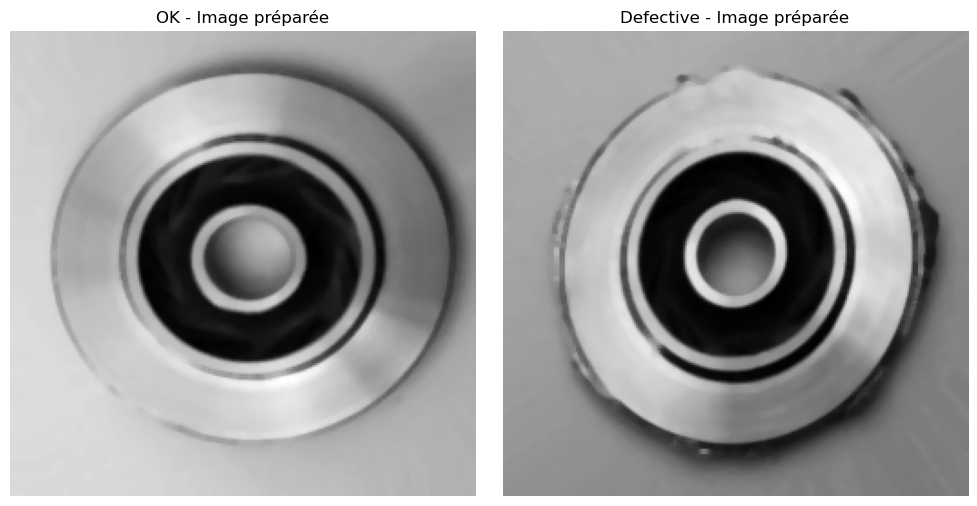

In [31]:
# ==========================================
# 4. Préparer les images
# ==========================================

ok_pre = preprocess_image(ok_img, target_size=(256, 256))
def_pre = preprocess_image(def_img, target_size=(256, 256))

# On choisit ici le filtre médian comme base
ok_base = apply_median_filter(ok_pre, kernel_size=5)
def_base = apply_median_filter(def_pre, kernel_size=5)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(ok_base, cmap="gray")
axes[0].set_title("OK - Image préparée")
axes[0].axis("off")

axes[1].imshow(def_base, cmap="gray")
axes[1].set_title("Defective - Image préparée")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [32]:
# ==========================================
# 5. Égalisation globale
# ==========================================

def apply_histogram_equalization(img):
    return cv2.equalizeHist(img)

In [33]:
# ==========================================
# 6. CLAHE
# ==========================================

def apply_clahe(img, clip_limit=2.0, tile_grid_size=(8, 8)):
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(img)

In [34]:
# ==========================================
# 7. Application des méthodes de contraste
# ==========================================

ok_equalized = apply_histogram_equalization(ok_base)
ok_clahe = apply_clahe(ok_base)

def_equalized = apply_histogram_equalization(def_base)
def_clahe = apply_clahe(def_base)

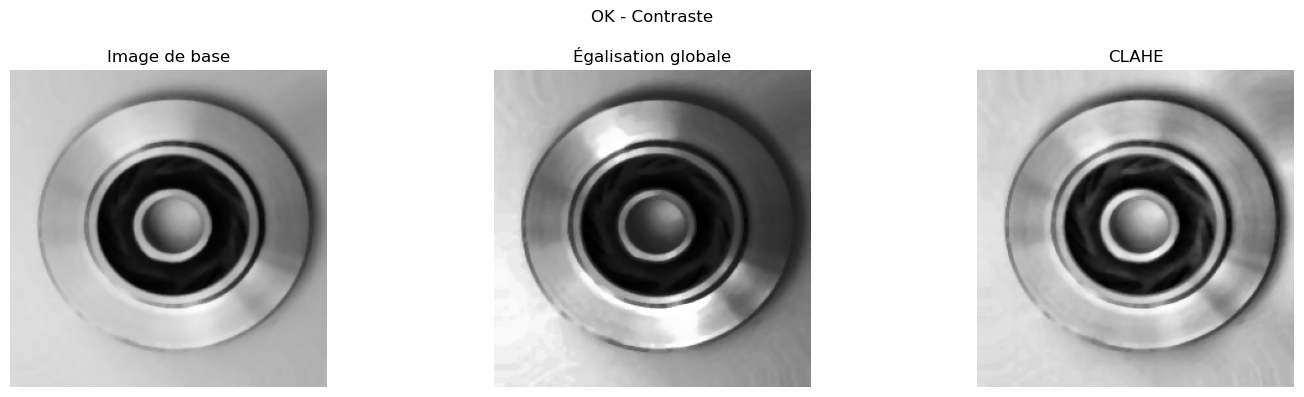

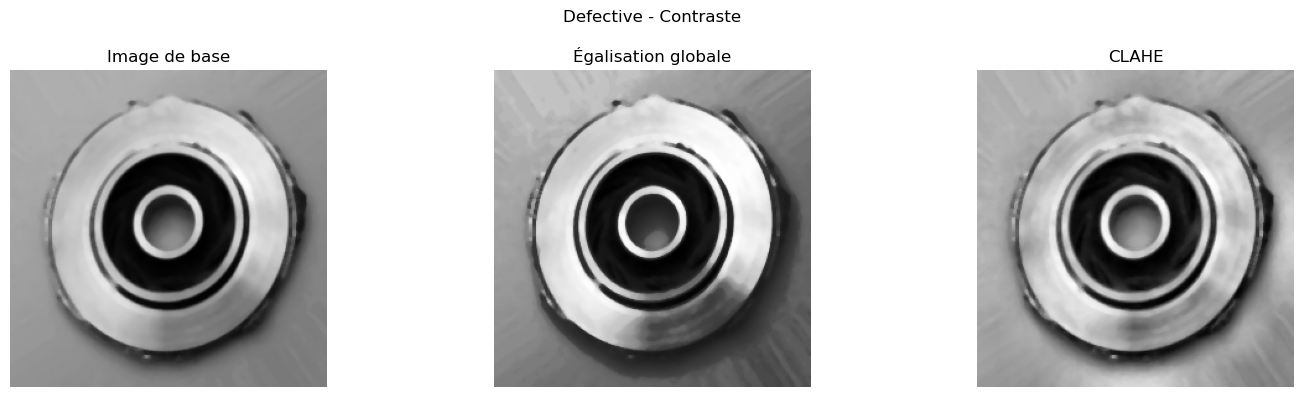

In [35]:
# ==========================================
# 8. Comparer les contrastes
# ==========================================

def compare_contrast_methods(base_img, equalized_img, clahe_img, title="Contraste"):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].imshow(base_img, cmap="gray")
    axes[0].set_title("Image de base")
    axes[0].axis("off")
    
    axes[1].imshow(equalized_img, cmap="gray")
    axes[1].set_title("Égalisation globale")
    axes[1].axis("off")
    
    axes[2].imshow(clahe_img, cmap="gray")
    axes[2].set_title("CLAHE")
    axes[2].axis("off")
    
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

compare_contrast_methods(ok_base, ok_equalized, ok_clahe, title="OK - Contraste")
compare_contrast_methods(def_base, def_equalized, def_clahe, title="Defective - Contraste")

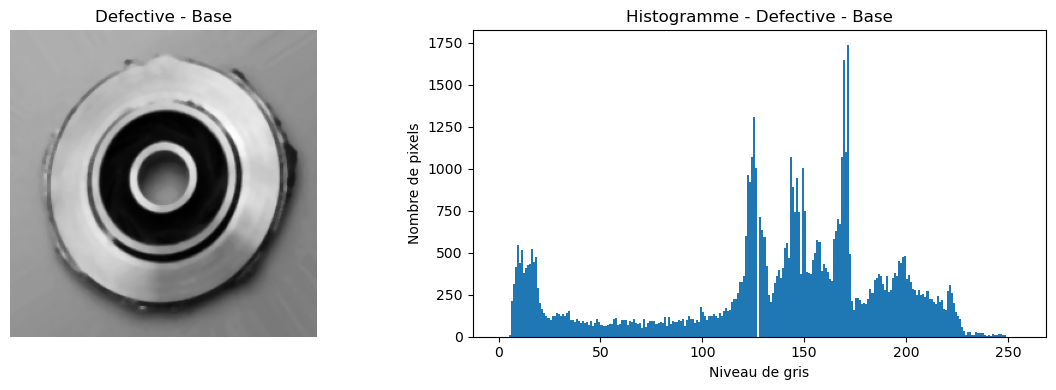

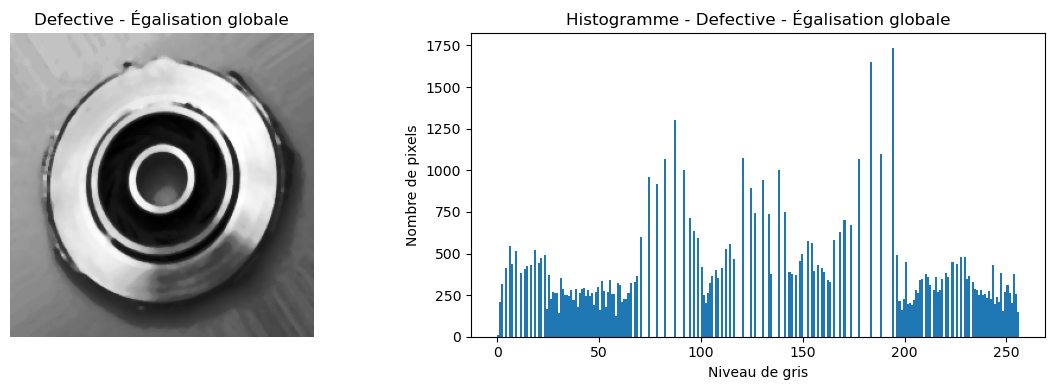

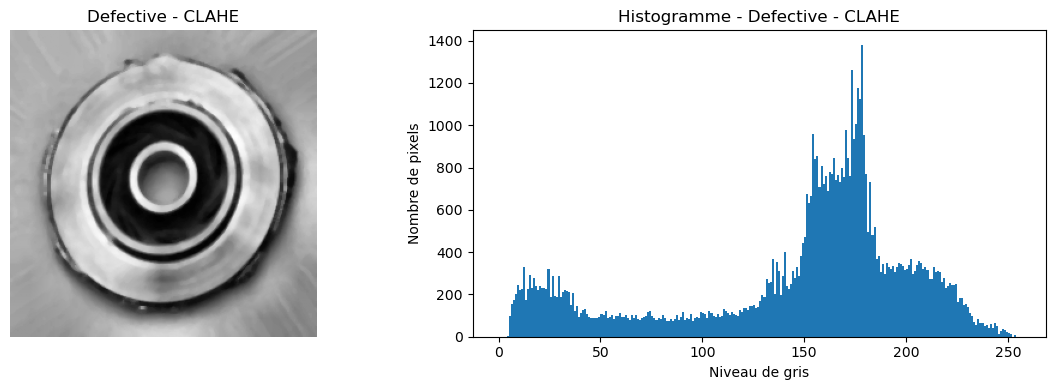

In [36]:
# ==========================================
# 9. Histogrammes après contraste
# ==========================================

plot_image_and_histogram(def_base, "Defective - Base")
plot_image_and_histogram(def_equalized, "Defective - Égalisation globale")
plot_image_and_histogram(def_clahe, "Defective - CLAHE")

In [37]:
# ==========================================
# 10. Image finale avant seuillage
# ==========================================

ok_ready = ok_clahe
def_ready = def_clahe

In [38]:
# ==========================================
# 11. Seuillage simple
# ==========================================

def apply_binary_threshold(img, thresh_value=127):
    _, binary = cv2.threshold(img, thresh_value, 255, cv2.THRESH_BINARY)
    return binary

def apply_binary_inverse_threshold(img, thresh_value=127):
    _, binary_inv = cv2.threshold(img, thresh_value, 255, cv2.THRESH_BINARY_INV)
    return binary_inv

In [39]:
# ==========================================
# 12. Seuillage d'Otsu
# ==========================================

def apply_otsu_threshold(img):
    thresh_value, otsu = cv2.threshold(
        img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )
    return otsu, thresh_value

In [40]:
# ==========================================
# 13. Seuillage adaptatif
# ==========================================

def apply_adaptive_mean_threshold(img, block_size=11, c=2):
    return cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_MEAN_C,
        cv2.THRESH_BINARY,
        block_size,
        c
    )

def apply_adaptive_gaussian_threshold(img, block_size=11, c=2):
    return cv2.adaptiveThreshold(
        img,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        block_size,
        c
    )

In [41]:
# ==========================================
# 14. Application des seuillages
# ==========================================

def_binary = apply_binary_threshold(def_ready, thresh_value=127)
def_binary_inv = apply_binary_inverse_threshold(def_ready, thresh_value=127)
def_otsu, def_otsu_value = apply_otsu_threshold(def_ready)
def_adapt_mean = apply_adaptive_mean_threshold(def_ready, block_size=11, c=2)
def_adapt_gauss = apply_adaptive_gaussian_threshold(def_ready, block_size=11, c=2)

print("Seuil trouvé par Otsu :", def_otsu_value)

Seuil trouvé par Otsu : 110.0


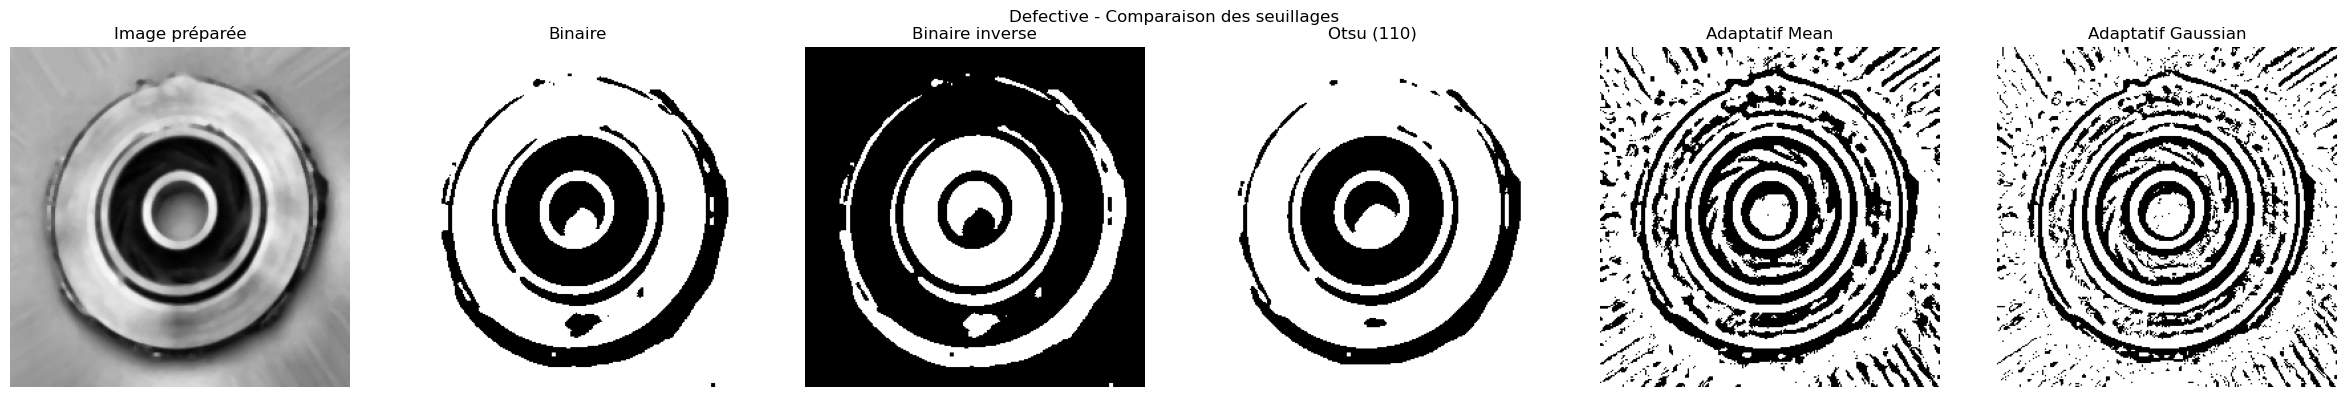

In [42]:
# ==========================================
# 15. Comparaison des seuillages
# ==========================================

def compare_threshold_methods(original, images, titles, main_title="Seuillages"):
    n = len(images) + 1
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    
    axes[0].imshow(original, cmap="gray")
    axes[0].set_title("Image préparée")
    axes[0].axis("off")
    
    for i, (img, title) in enumerate(zip(images, titles), start=1):
        axes[i].imshow(img, cmap="gray")
        axes[i].set_title(title)
        axes[i].axis("off")
    
    plt.suptitle(main_title)
    plt.tight_layout()
    plt.show()

compare_threshold_methods(
    def_ready,
    [def_binary, def_binary_inv, def_otsu, def_adapt_mean, def_adapt_gauss],
    ["Binaire", "Binaire inverse", f"Otsu ({def_otsu_value:.0f})", "Adaptatif Mean", "Adaptatif Gaussian"],
    main_title="Defective - Comparaison des seuillages"
)

In [ ]:
# ==========================================
# 16. Détection des contours
# ==========================================

def detect_contours(binary_img, retrieval_mode=cv2.RETR_EXTERNAL, approx_method=cv2.CHAIN_APPROX_SIMPLE):
    contours, hierarchy = cv2.findContours(binary_img.copy(), retrieval_mode, approx_method)
    return contours, hierarchy

In [44]:
# ==========================================
# 17. Dessiner les contours
# ==========================================

def draw_contours_on_image(gray_img, contours, thickness=2):
    img_rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)
    cv2.drawContours(img_rgb, contours, -1, (255, 0, 0), thickness)
    return img_rgb

Nombre de contours détectés : 1


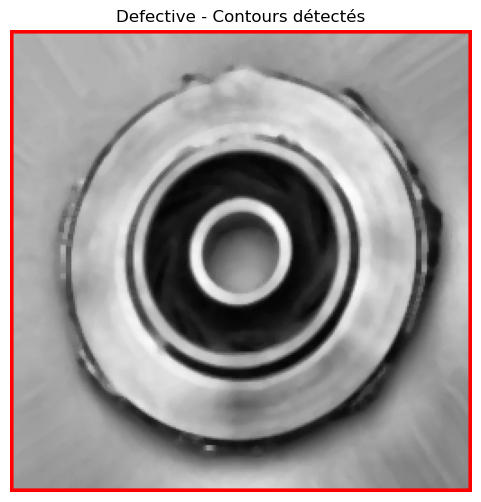

In [45]:
# ==========================================
# 18. Contours sur image seuillée
# ==========================================

def_contours, _ = detect_contours(def_otsu)
print("Nombre de contours détectés :", len(def_contours))

def_contours_img = draw_contours_on_image(def_ready, def_contours, thickness=2)

plt.figure(figsize=(6, 6))
plt.imshow(def_contours_img)
plt.title("Defective - Contours détectés")
plt.axis("off")
plt.show()

In [46]:
# ==========================================
# 19. Filtrer les petits contours
# ==========================================

def filter_contours_by_area(contours, min_area=20):
    return [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]

def_contours_filtered = filter_contours_by_area(def_contours, min_area=20)

print("Contours avant filtrage :", len(def_contours))
print("Contours après filtrage :", len(def_contours_filtered))

Contours avant filtrage : 1
Contours après filtrage : 1


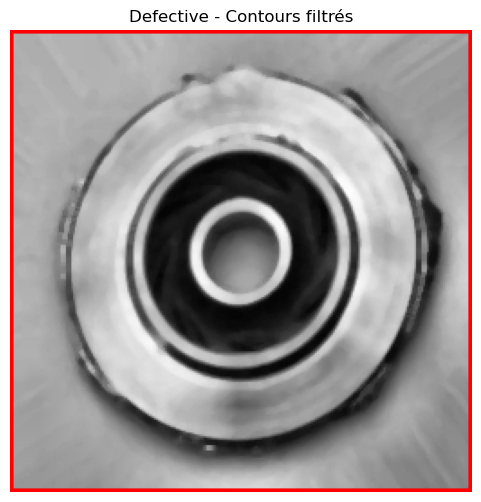

In [47]:
# ==========================================
# 20. Contours filtrés
# ==========================================

def_filtered_img = draw_contours_on_image(def_ready, def_contours_filtered, thickness=2)

plt.figure(figsize=(6, 6))
plt.imshow(def_filtered_img)
plt.title("Defective - Contours filtrés")
plt.axis("off")
plt.show()

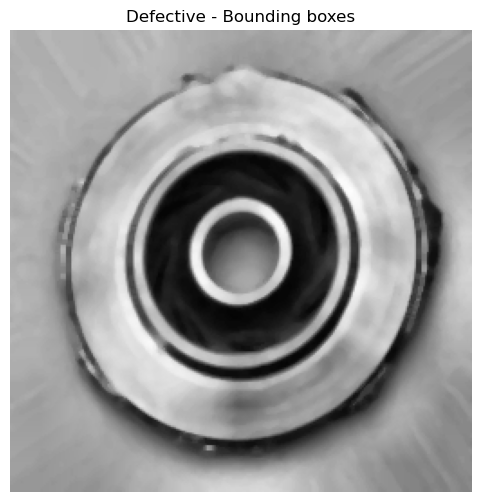

In [48]:
# ==========================================
# 21. Bounding boxes
# ==========================================

def draw_bounding_boxes(gray_img, contours, thickness=2, min_area=10):
    img_rgb = cv2.cvtColor(gray_img, cv2.COLOR_GRAY2RGB)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area:
            continue

        x, y, w, h = cv2.boundingRect(cnt)

        H, W = gray_img.shape
        if w > 0.95 * W and h > 0.95 * H:
            continue

        cv2.rectangle(img_rgb, (x, y), (x + w, y + h), (255, 0, 0), thickness)

    return img_rgb

def_boxes_img = draw_bounding_boxes(def_ready, def_contours_filtered, thickness=2, min_area=10)

plt.figure(figsize=(6, 6))
plt.imshow(def_boxes_img)
plt.title("Defective - Bounding boxes")
plt.axis("off")
plt.show()

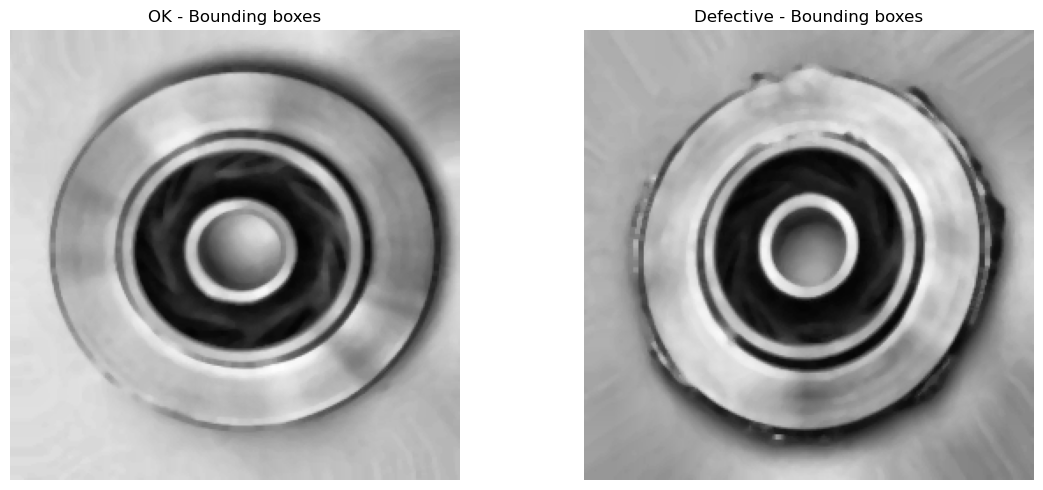

Contours filtrés OK       : 1
Contours filtrés Defective: 1


In [49]:
# ==========================================
# 22. Comparaison OK vs Defective
# ==========================================

ok_otsu, ok_otsu_value = apply_otsu_threshold(ok_ready)
ok_contours, _ = detect_contours(ok_otsu)
ok_contours_filtered = filter_contours_by_area(ok_contours, min_area=20)

ok_boxes_img = draw_bounding_boxes(ok_ready, ok_contours_filtered, thickness=2, min_area=10)
def_boxes_img = draw_bounding_boxes(def_ready, def_contours_filtered, thickness=2, min_area=10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(ok_boxes_img)
axes[0].set_title("OK - Bounding boxes")
axes[0].axis("off")

axes[1].imshow(def_boxes_img)
axes[1].set_title("Defective - Bounding boxes")
axes[1].axis("off")

plt.tight_layout()
plt.show()

print("Contours filtrés OK       :", len(ok_contours_filtered))
print("Contours filtrés Defective:", len(def_contours_filtered))